In [1]:
import pandas as pd
import numpy as np


In [2]:
data = pd.read_csv("../../data/Social_Network_Ads.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [4]:
features = data.iloc[:, [0,1]].values
labels = data.iloc[:, [2]].values

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=1
)

In [6]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [7]:
print(f"Train Score: {model.score(X_train, y_train)}, Test Score: {model.score(X_test, y_test)}")

Train Score: 0.996875, Test Score: 0.8125


In [9]:
model.tree_.max_depth

13

[Text(0.48355263157894735, 0.9642857142857143, 'age <= 44.5\ngini = 0.453\nsamples = 320\nvalue = [209, 111]\nclass = 0'),
 Text(0.27631578947368424, 0.8928571428571429, 'salary <= 90500.0\ngini = 0.275\nsamples = 237\nvalue = [198, 39]\nclass = 0'),
 Text(0.3799342105263158, 0.9285714285714286, 'True  '),
 Text(0.15789473684210525, 0.8214285714285714, 'age <= 36.5\ngini = 0.067\nsamples = 201\nvalue = [194, 7]\nclass = 0'),
 Text(0.13157894736842105, 0.75, 'gini = 0.0\nsamples = 134\nvalue = [134, 0]\nclass = 0'),
 Text(0.18421052631578946, 0.75, 'salary <= 83500.0\ngini = 0.187\nsamples = 67\nvalue = [60, 7]\nclass = 0'),
 Text(0.15789473684210525, 0.6785714285714286, 'salary <= 67500.0\ngini = 0.142\nsamples = 65\nvalue = [60, 5]\nclass = 0'),
 Text(0.13157894736842105, 0.6071428571428571, 'gini = 0.0\nsamples = 35\nvalue = [35, 0]\nclass = 0'),
 Text(0.18421052631578946, 0.6071428571428571, 'salary <= 70500.0\ngini = 0.278\nsamples = 30\nvalue = [25, 5]\nclass = 0'),
 Text(0.157894

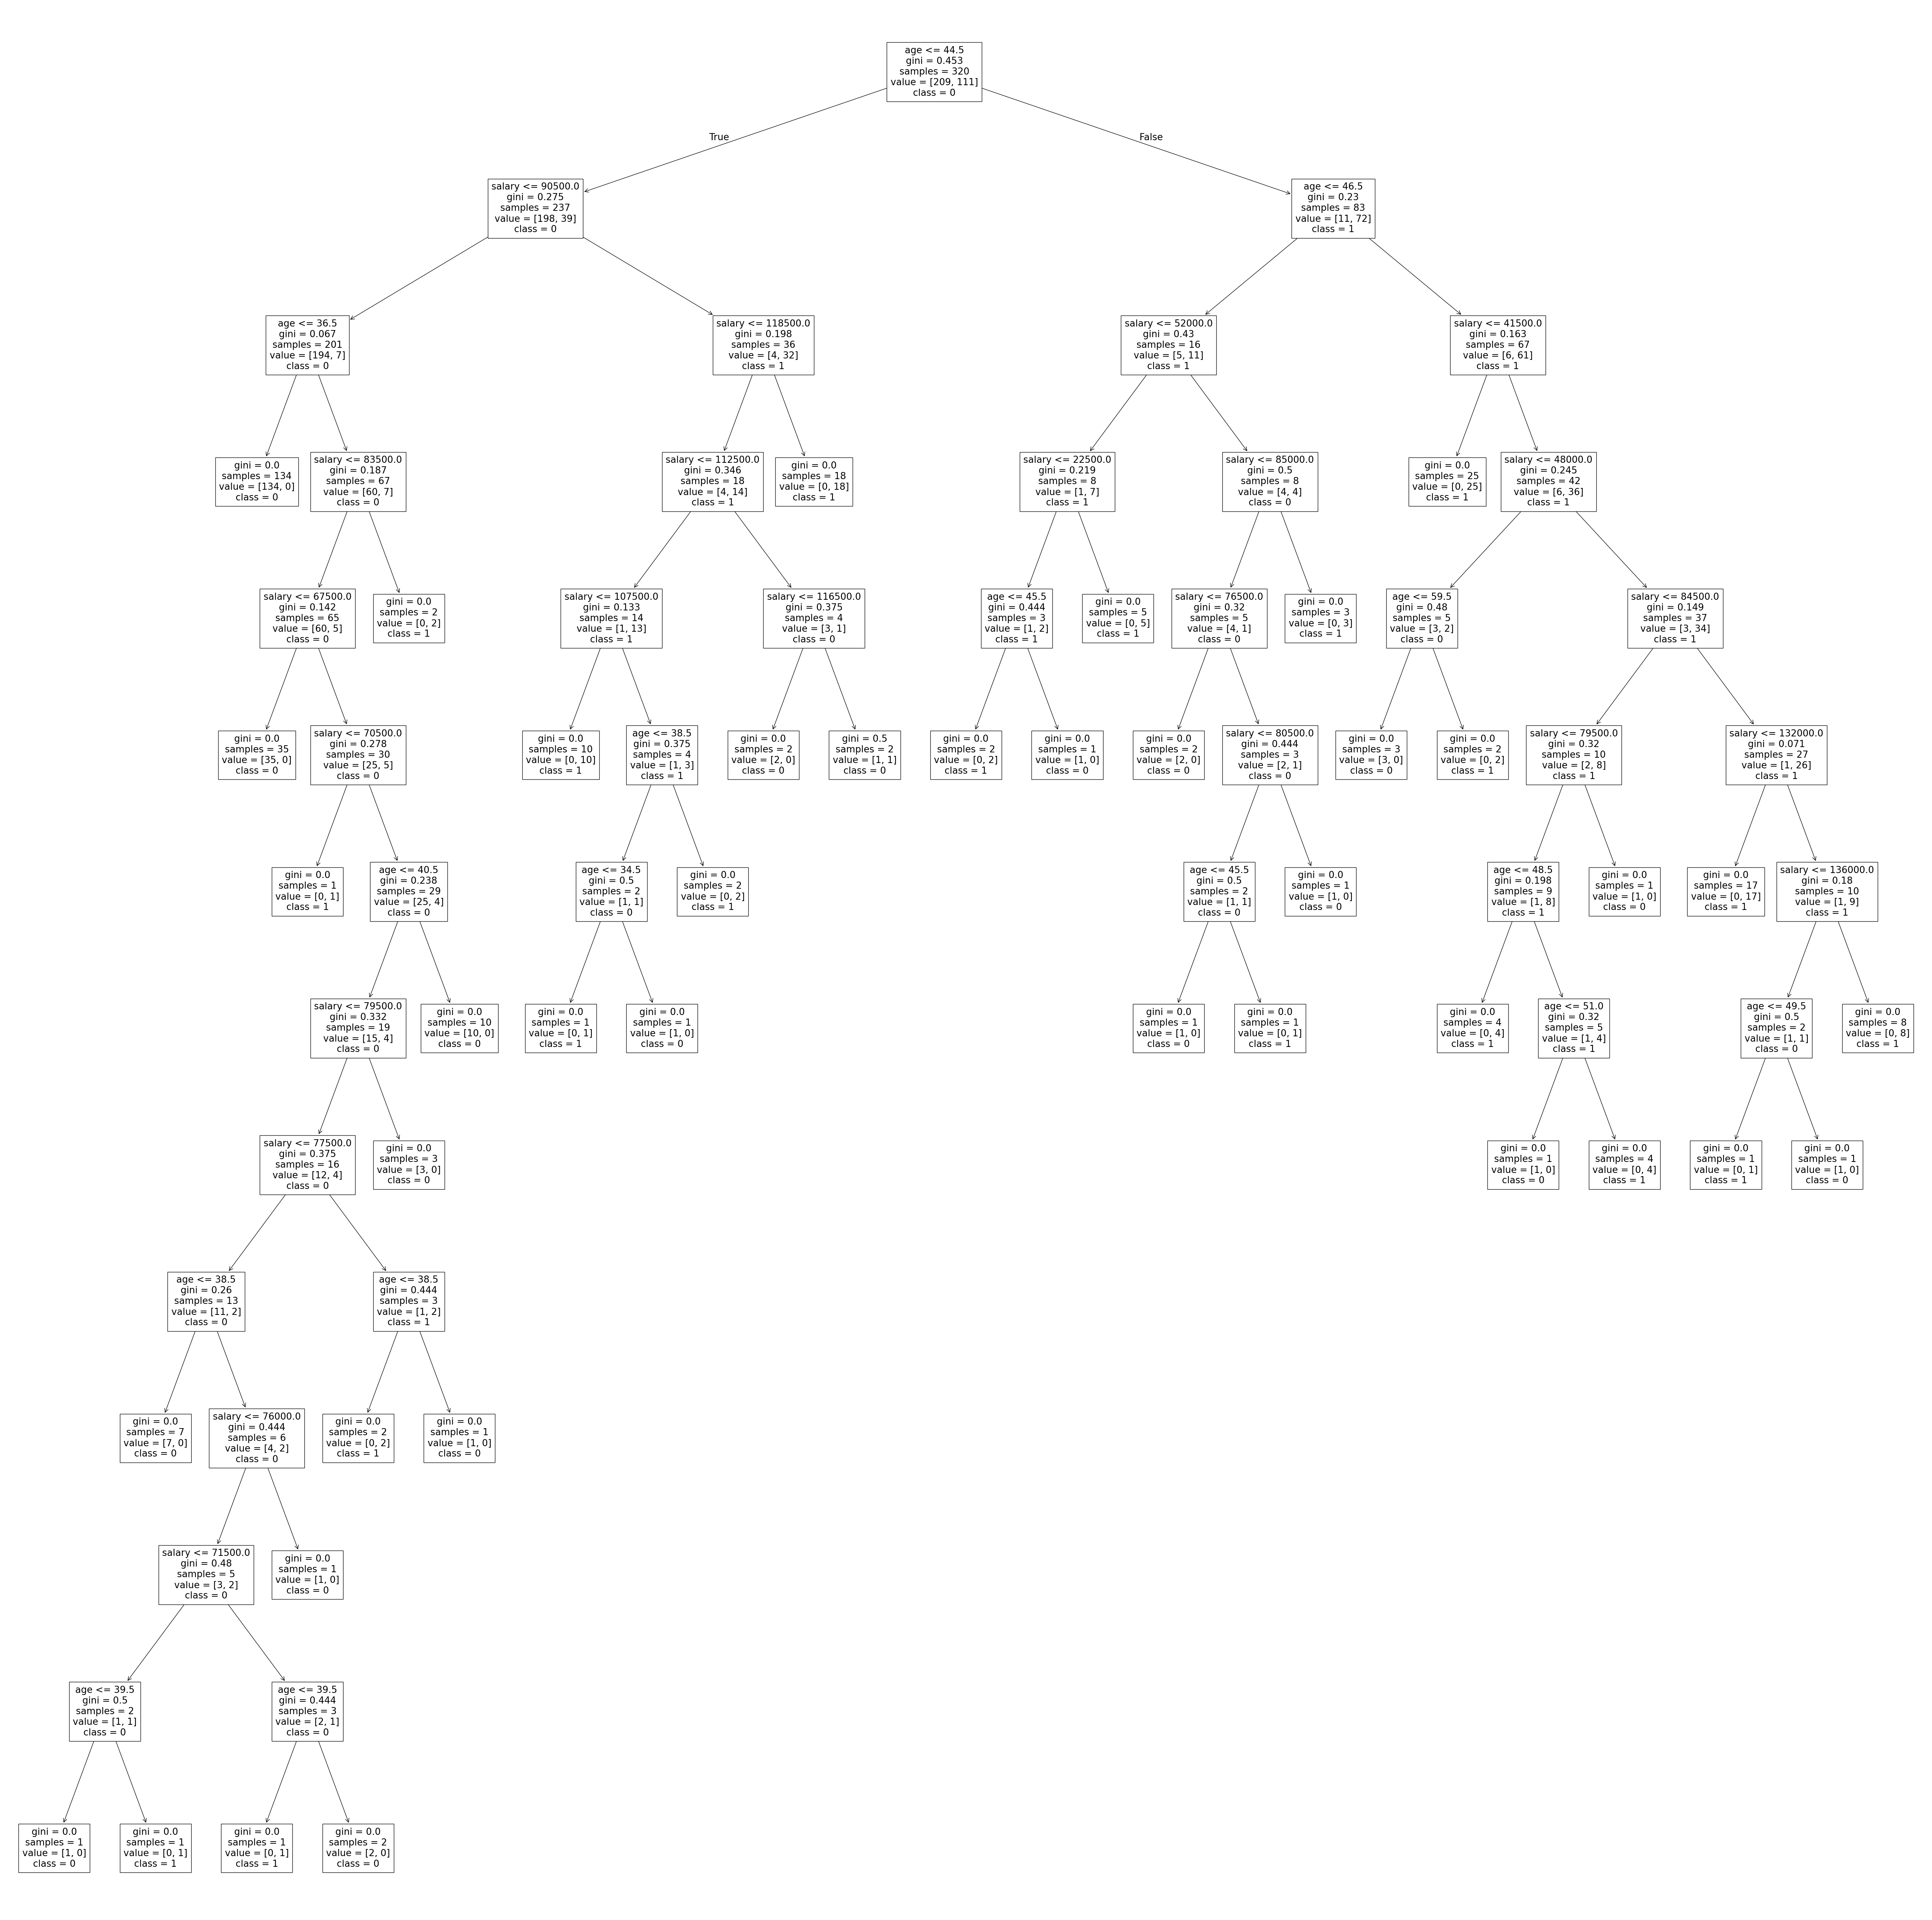

In [10]:
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

plt.figure(figsize=(70, 70))
plot_tree(model, 
          feature_names=['age', 'salary'],
          class_names=['0', '1'])

In [11]:
#Observation of code: Decision tree tends to OVERFIT. It is his default nature. This nature can be controlled by
# playing with max_depth parameter

In [16]:
SL = 0.2
CL = 1 - SL
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

for rs in range(1,300):
  X_train,X_test,y_train,y_test = train_test_split(features,
                                                   labels,
                                                   test_size=0.2,
                                                   random_state=rs)

  model = DecisionTreeClassifier(max_depth=10)
  model.fit(X_train,y_train)
  trainScore = model.score(X_train,y_train)
  testScore = model.score(X_test,y_test)

  if testScore > trainScore and testScore >= CL:
    print(f"TestScore is {testScore}, trainScore is {trainScore}, rs is {rs}")

In [22]:
# Since the ground truth of DecisionTree is the model TENDS TO OVERFIT. Thus we needed a system
# that can CONTROL the OVERFITTING. Thus came RANDOMFOREST algo.

# RandomForest is nothing with BaggingClassifier with DT algo

#BaggingClassifier(base_estimator=DecisionTreeClassifier())

SL = 0.2
CL = 1 - SL
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

for rs in range(1,300):
  X_train,X_test,y_train,y_test = train_test_split(features,
                                                   labels,
                                                   test_size=0.2,
                                                   random_state=rs)
  
  y_train = y_train.ravel()
  y_test = y_test.ravel()

  model = RandomForestClassifier(max_depth=4)
  model.fit(X_train,y_train)
  trainScore = model.score(X_train,y_train)
  testScore = model.score(X_test,y_test)

  if testScore > trainScore and testScore >= CL:
    print(f"TestScore is {testScore}, trainScore is {trainScore}, rs is {rs}")

TestScore is 0.9375, trainScore is 0.93125, rs is 21
TestScore is 0.9625, trainScore is 0.928125, rs is 24
TestScore is 0.9375, trainScore is 0.91875, rs is 25
TestScore is 0.95, trainScore is 0.93125, rs is 30
TestScore is 0.95, trainScore is 0.91875, rs is 33
TestScore is 0.9375, trainScore is 0.928125, rs is 35
TestScore is 0.925, trainScore is 0.921875, rs is 39
TestScore is 0.9375, trainScore is 0.934375, rs is 50
TestScore is 0.9375, trainScore is 0.921875, rs is 58
TestScore is 0.95, trainScore is 0.928125, rs is 61
TestScore is 0.9375, trainScore is 0.925, rs is 65
TestScore is 0.9375, trainScore is 0.925, rs is 66
TestScore is 0.9375, trainScore is 0.93125, rs is 67
TestScore is 0.925, trainScore is 0.921875, rs is 68
TestScore is 0.9375, trainScore is 0.925, rs is 72
TestScore is 0.9375, trainScore is 0.928125, rs is 73
TestScore is 0.975, trainScore is 0.91875, rs is 76
TestScore is 0.95, trainScore is 0.925, rs is 77
TestScore is 0.9375, trainScore is 0.928125, rs is 79
Tes

In [19]:

y_train = y_train.ravel()
y_test = y_test.ravel()

model = RandomForestClassifier(max_depth=4)
model.fit(X_train, y_train)

print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.925
Test Score: 0.95
